In [1]:
import sys
print(sys.executable)

/Users/gcrane/venvs/alignment/bin/python


In [2]:
import sys

!{sys.executable} -m pip install \
    torch \
    tokenizers==0.15.2 \
    transformers==4.38.2 \
    sentencepiece \
    protobuf \
    scipy \
    networkx \
    matplotlib \
    "huggingface_hub<0.22" \
    lxml \
    pandas \
    beautifulsoup4 \
    regex \
    tqdm \
    ipywidgets

# Comparing Two TEI Editions of Aristotle's *Poetics*

This notebook compares:
- **Butcher 1911 Greek** (`tlg0086.tlg034.bywater1909-grc.xml`) — LLM-produced TEI with `<lb>` line breaks and end-of-line hyphens
- **Perseus/Kassel Greek** (`tlg0086.tlg034.perseus-grc2.xml`) — the reference Perseus Digital Library edition
- **Butcher 1911 English** (`tlg0086.tlg034.bywater1909-eng2.xml`) — Butcher's English translation, aligned by chapter/section

**Part A** — Greek vs. Greek: verify no words were dropped and chapter/section divs match
**Part B** — Greek + English: side-by-side display for aligned sections

In [3]:
import re, unicodedata, json
from collections import OrderedDict, defaultdict
from lxml import etree
from difflib import SequenceMatcher
from IPython.display import display, HTML, Markdown

## 0. File paths

Edit these paths to match your local setup.

In [4]:
# ── EDIT THESE PATHS ──
BUTCHER_GRC = '/Users/gcrane/github/Poetics2.0/grc/tlg0086.tlg034.bywater1909-grc1.xml'
PERSEUS_GRC = '/Users/gcrane/github/canonical-greekLit/data/tlg0086/tlg034/tlg0086.tlg034.perseus-grc2.xml'
BUTCHER_ENG = '/Users/gcrane/github/Poetics2.0/grc/tlg0086.tlg034.bywater1909-eng1.xml'

## 1. Parse all XML files

In [5]:
NS = {'tei': 'http://www.tei-c.org/ns/1.0'}

butcher_tree = etree.parse(BUTCHER_GRC)
perseus_tree = etree.parse(PERSEUS_GRC)
english_tree = etree.parse(BUTCHER_ENG)

print('Butcher Greek root tag:', butcher_tree.getroot().tag)
print('Perseus Greek root tag:', perseus_tree.getroot().tag)
print('Butcher English root tag:', english_tree.getroot().tag)

Butcher Greek root tag: {http://www.tei-c.org/ns/1.0}TEI
Perseus Greek root tag: {http://www.tei-c.org/ns/1.0}TEI
Butcher English root tag: {http://www.tei-c.org/ns/1.0}TEI


## 2. Text extraction and normalization

The Butcher Greek has `<lb>` line breaks and **end-of-line hyphens** (e.g. `πρῶ-` / `τον`).
Both files have `<del>`, `<add>`, `<quote>`, `[cite: N]` markers, and `<note>` elements.

In [6]:
def extract_text_from_element(el):
    """Recursively extract all text content from an XML element,
    including text inside <add>, <del>, <quote> children,
    but EXCLUDING <note> elements.
    Treats <lb/>, <pb/>, <milestone/> as space boundaries.
    """
    parts = []

    def _walk(node):
        tag = etree.QName(node.tag).localname if isinstance(node.tag, str) else ''
        if tag == 'note':
            if node.tail:
                parts.append(node.tail)
            return
        if tag in ('lb', 'pb', 'milestone'):
            parts.append(' ')
            if node.tail:
                parts.append(node.tail)
            return
        if node.text:
            parts.append(node.text)
        for child in node:
            _walk(child)
        if node.tail:
            parts.append(node.tail)

    _walk(el)
    return ''.join(parts)


def normalize_greek(text):
    """Normalize extracted Greek text for comparison."""
    text = re.sub(r'\[cite:\s*\d+\]', '', text)
    text = re.sub(r'(\S)-\s+', r'\1', text)
    text = unicodedata.normalize('NFC', text)
    text = text.replace('\u2019', '\'')
    text = text.replace('\u02BC', '\'')
    text = text.replace('\u1FBD', '\'')
    text = text.replace('\u2018', '')
    text = re.sub(r'\.\s*\.\s*\.\s*\.?', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def normalize_english(text):
    """Normalize extracted English text."""
    text = re.sub(r'\[cite:\s*\d+\]', '', text)
    text = re.sub(r'(\S)-\s+', r'\1', text)
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def section_sort_key(s):
    """Sort key for section numbers like '11b', '10c'."""
    m = re.match(r'(\d+)(.*)', s)
    if m:
        return (int(m.group(1)), m.group(2))
    return (0, s)


def tokenize(text):
    """Split text into word tokens, stripping boundary punctuation."""
    tokens = text.split()
    cleaned = []
    for t in tokens:
        t = re.sub(r'^[^\w\u0370-\u03FF\u1F00-\u1FFF]+', '', t)
        t = re.sub(r'[^\w\u0370-\u03FF\u1F00-\u1FFF]+$', '', t)
        if t:
            cleaned.append(t)
    return cleaned


def chapter_full_text(ch_dict):
    """Concatenate all sections of a chapter in section order."""
    return ' '.join(ch_dict[s] for s in sorted(ch_dict.keys(), key=section_sort_key))


# Quick test
test = "πρῶ- [cite: 4]\n            τον ἀπὸ τῶν πρώτων. [cite: 4]"
print(repr(normalize_greek(test)))

'πρῶτον ἀπὸ τῶν πρώτων.'


## 3. Build chapter → section dictionaries

In [7]:
def build_chapter_dict(tree, ch_tag_attr, sec_tag_attr):
    """Generic builder for both Butcher and Perseus XML structures.
    ch_tag_attr / sec_tag_attr are (attribute_name, attribute_value) tuples.
    Duplicate chapter divs (Butcher page-break splits) are merged.
    """
    ch_attr, ch_val = ch_tag_attr
    sec_attr, sec_val = sec_tag_attr
    chapters = OrderedDict()
    for ch_div in tree.xpath(f'//tei:div[@{ch_attr}="{ch_val}"]', namespaces=NS):
        ch_n = ch_div.get('n')
        if ch_n not in chapters:
            chapters[ch_n] = OrderedDict()
        for sec_div in ch_div.xpath(f'tei:div[@{sec_attr}="{sec_val}"]', namespaces=NS):
            sec_n = sec_div.get('n')
            raw = extract_text_from_element(sec_div)
            chapters[ch_n][sec_n] = raw
    return chapters


def build_and_normalize(tree, ch_tag, sec_tag, normalizer):
    raw = build_chapter_dict(tree, ch_tag, sec_tag)
    return OrderedDict(
        (ch, OrderedDict((s, normalizer(txt)) for s, txt in secs.items()))
        for ch, secs in raw.items()
    )


butcher = build_and_normalize(butcher_tree, ('subtype', 'chapter'), ('subtype', 'section'), normalize_greek)
perseus = build_and_normalize(perseus_tree, ('subtype', 'chapter'), ('subtype', 'subchapter'), normalize_greek)
english = build_and_normalize(english_tree, ('subtype', 'chapter'), ('subtype', 'section'), normalize_english)

print(f'Butcher Greek:   {len(butcher)} chapters, {sum(len(s) for s in butcher.values())} sections')
print(f'Perseus Greek:   {len(perseus)} chapters, {sum(len(s) for s in perseus.values())} sections')
print(f'Butcher English: {len(english)} chapters, {sum(len(s) for s in english.values())} sections')

Butcher Greek:   26 chapters, 381 sections
Perseus Greek:   26 chapters, 381 sections
Butcher English: 26 chapters, 380 sections


---
# Part A — Greek vs. Greek Comparison

## 4. Compare chapter/section structure

In [8]:
all_chapters = sorted(set(butcher.keys()) | set(perseus.keys()), key=section_sort_key)

rows = []
for ch in all_chapters:
    b_secs = sorted(butcher.get(ch, {}).keys(), key=section_sort_key)
    p_secs = sorted(perseus.get(ch, {}).keys(), key=section_sort_key)
    b_set, p_set = set(b_secs), set(p_secs)
    only_b = sorted(b_set - p_set, key=section_sort_key)
    only_p = sorted(p_set - b_set, key=section_sort_key)
    match = '✅' if b_set == p_set else '❌'
    rows.append({
        'chapter': ch, 'butcher_sections': len(b_secs), 'perseus_sections': len(p_secs),
        'match': match, 'only_in_butcher': ', '.join(only_b), 'only_in_perseus': ', '.join(only_p),
    })

html = '<table border="1" cellpadding="4" style="border-collapse:collapse">'
html += '<tr><th>Chapter</th><th>Butcher §</th><th>Perseus §</th><th>Match</th><th>Only Butcher</th><th>Only Perseus</th></tr>'
for r in rows:
    color = '' if r['match'] == '✅' else ' style="background:#ffe0e0"'
    html += f'<tr{color}><td>{r["chapter"]}</td><td>{r["butcher_sections"]}</td><td>{r["perseus_sections"]}</td>'
    html += f'<td>{r["match"]}</td><td>{r["only_in_butcher"]}</td><td>{r["only_in_perseus"]}</td></tr>'
html += '</table>'
display(HTML(html))

Chapter,Butcher §,Perseus §,Match,Only Butcher,Only Perseus
1,14,14,✅,,
2,7,7,✅,,
3,7,7,✅,,
4,21,21,✅,,
5,11,11,✅,,
6,28,28,✅,,
7,12,12,✅,,
8,4,4,✅,,
9,15,15,✅,,
10,4,4,✅,,


## 5. Word-level comparison per chapter

In [9]:
def compare_word_lists(words_a, words_b):
    """Returns (only_in_a, only_in_b, common_count, ratio)."""
    sm = SequenceMatcher(None, words_a, words_b, autojunk=False)
    only_a, only_b, common = [], [], 0
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'equal':
            common += (i2 - i1)
        elif tag == 'delete':
            only_a.extend((k, words_a[k]) for k in range(i1, i2))
        elif tag == 'insert':
            only_b.extend((k, words_b[k]) for k in range(j1, j2))
        elif tag == 'replace':
            only_a.extend((k, words_a[k]) for k in range(i1, i2))
            only_b.extend((k, words_b[k]) for k in range(j1, j2))
    return only_a, only_b, common, sm.ratio()

In [10]:
chapter_results = []
for ch in all_chapters:
    b_text = chapter_full_text(butcher[ch]) if ch in butcher else ''
    p_text = chapter_full_text(perseus[ch]) if ch in perseus else ''
    b_words, p_words = tokenize(b_text), tokenize(p_text)
    only_b, only_p, common, ratio = compare_word_lists(b_words, p_words)
    chapter_results.append({
        'chapter': ch, 'butcher_words': len(b_words), 'perseus_words': len(p_words),
        'common': common, 'only_butcher': only_b, 'only_perseus': only_p, 'ratio': ratio,
    })

html = '<h3>Word-level comparison per chapter</h3>'
html += '<table border="1" cellpadding="4" style="border-collapse:collapse; font-size:13px">'
html += '<tr><th>Ch</th><th>Butcher</th><th>Perseus</th><th>Shared</th><th>Only B</th><th>Only P</th><th>Sim</th></tr>'
for r in chapter_results:
    ob, op = len(r['only_butcher']), len(r['only_perseus'])
    color = ''
    if ob > 0 or op > 0:
        color = ' style="background:#fff3cd"' if r['ratio'] > 0.95 else ' style="background:#ffe0e0"'
    html += f'<tr{color}><td>{r["chapter"]}</td><td>{r["butcher_words"]}</td><td>{r["perseus_words"]}</td>'
    html += f'<td>{r["common"]}</td><td>{ob}</td><td>{op}</td><td>{r["ratio"]:.3f}</td></tr>'
html += '</table>'
display(HTML(html))

Ch,Butcher,Perseus,Shared,Only B,Only P,Sim
1,406,406,394,12,12,0.970
2,160,161,155,5,6,0.966
3,203,203,201,2,2,0.990
4,567,569,560,7,9,0.986
5,236,236,234,2,2,0.992
6,716,715,701,15,14,0.980
7,316,319,311,5,8,0.980
8,187,188,184,3,4,0.981
9,475,477,473,2,4,0.994
10,88,90,86,2,4,0.966


## 6. Detailed chapter diffs

In [11]:
for r in chapter_results:
    if not r['only_butcher'] and not r['only_perseus']:
        continue
    ch = r['chapter']
    print(f"\n{'='*70}")
    print(f"Chapter {ch}  (similarity: {r['ratio']:.3f})")
    print(f"{'='*70}")
    if r['only_butcher']:
        print(f"\n  Words ONLY in Butcher ({len(r['only_butcher'])}):\n")
        for pos, w in r['only_butcher']:
            print(f"    [{pos:4d}] {w}")
    if r['only_perseus']:
        print(f"\n  Words ONLY in Perseus ({len(r['only_perseus'])}):\n")
        for pos, w in r['only_perseus']:
            print(f"    [{pos:4d}] {w}")


Chapter 1  (similarity: 0.970)

  Words ONLY in Butcher (12):

    [   0] Περὶ
    [   8] ἦν
    [  22] ἔξειν
    [  47] φύσω
    [  85] γένει
    [ 123] κὰν
    [ 161] τυγχάνουσιν
    [ 201] ἢ
    [ 208] μετ᾿
    [ 217] ἀνώνυμος
    [ 218] τυγχάνει
    [ 219] οὖσα

  Words ONLY in Perseus (12):

    [   0] περὶ
    [   8] ἥν
    [  22] ἕξειν
    [  47] φύσιν
    [  85] ἐν
    [ 123] κἀν
    [ 161] τυγχάνωσιν
    [ 201] καὶ
    [ 202] ἡ
    [ 209] μετ
    [ 218] ἀνώνυμοι
    [ 219] τυγχάνουσι

Chapter 2  (similarity: 0.966)

  Words ONLY in Butcher (5):

    [   0] Ἐπεὶ
    [  62] ἔξει
    [  70] ἔτερα
    [  89] τῷ
    [ 138] ταύτῃ

  Words ONLY in Perseus (6):

    [   0] ἐπεὶ
    [  62] ἕξει
    [  70] ἕτερα
    [  89] τὸ
    [ 130] γᾶς
    [ 139] αὐτῇ

Chapter 3  (similarity: 0.990)

  Words ONLY in Butcher (2):

    [   0] Ἔτι
    [  40] πάντα

  Words ONLY in Perseus (2):

    [   0] ἔτι
    [  40] πάντας

Chapter 4  (similarity: 0.986)

  Words ONLY in Butcher (7):

    [   0] 

## 7. Section-level comparison — full word accounting

Every section in either edition is shown. Sections only in one edition appear in full
so no words are silently skipped. Totals at the end confirm every word is accounted for.

In [12]:
def html_word_diff(text_a, text_b, label_a='Butcher', label_b='Perseus'):
    words_a, words_b = text_a.split(), text_b.split()
    sm = SequenceMatcher(None, words_a, words_b, autojunk=False)
    html_a, html_b = [], []
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'equal':
            chunk = ' '.join(words_a[i1:i2])
            html_a.append(chunk); html_b.append(chunk)
        elif tag == 'delete':
            html_a.append(f'<span style="background:#ffa0a0;font-weight:bold">{" ".join(words_a[i1:i2])}</span>')
        elif tag == 'insert':
            html_b.append(f'<span style="background:#a0ffa0;font-weight:bold">{" ".join(words_b[j1:j2])}</span>')
        elif tag == 'replace':
            html_a.append(f'<span style="background:#ffa0a0;font-weight:bold">{" ".join(words_a[i1:i2])}</span>')
            html_b.append(f'<span style="background:#a0ffa0;font-weight:bold">{" ".join(words_b[j1:j2])}</span>')
    return (f'<div style="margin:4px 0"><b>{label_a}:</b> {" ".join(html_a)}</div>'
            f'<div style="margin:4px 0"><b>{label_b}:</b> {" ".join(html_b)}</div>')

In [13]:
diff_count = 0
identical_count = 0
only_butcher_secs = 0
only_perseus_secs = 0
words_compared_b = 0
words_compared_p = 0

html_parts = ['<h3>Section-level comparison (all sections, both editions)</h3>']

for ch in all_chapters:
    b_secs = set(butcher.get(ch, {}).keys())
    p_secs = set(perseus.get(ch, {}).keys())
    all_secs = sorted(b_secs | p_secs, key=section_sort_key)

    for sec in all_secs:
        in_b = sec in b_secs
        in_p = sec in p_secs
        if in_b:
            words_compared_b += len(butcher[ch][sec].split())
        if in_p:
            words_compared_p += len(perseus[ch][sec].split())

        if in_b and in_p:
            b_text, p_text = butcher[ch][sec], perseus[ch][sec]
            if b_text == p_text:
                identical_count += 1
                continue
            diff_count += 1
            html_parts.append(
                f'<div style="border:1px solid #ccc; padding:8px; margin:8px 0; border-radius:4px">'
                f'<b>Ch {ch} §{sec}</b><br>{html_word_diff(b_text, p_text)}</div>')
        elif in_b:
            only_butcher_secs += 1
            html_parts.append(
                f'<div style="border:1px solid #e88; padding:8px; margin:8px 0; border-radius:4px; background:#fff5f5">'
                f'<b>Ch {ch} §{sec}</b> — <em>only in Butcher</em><br>'
                f'<div style="margin:4px 0">{butcher[ch][sec]}</div></div>')
        else:
            only_perseus_secs += 1
            html_parts.append(
                f'<div style="border:1px solid #8e8; padding:8px; margin:8px 0; border-radius:4px; background:#f5fff5">'
                f'<b>Ch {ch} §{sec}</b> — <em>only in Perseus</em><br>'
                f'<div style="margin:4px 0">{perseus[ch][sec]}</div></div>')

# Word accounting
butcher_total = sum(len(t.split()) for ch in butcher.values() for t in ch.values())
perseus_total = sum(len(t.split()) for ch in perseus.values() for t in ch.values())

b_check = '✅' if words_compared_b == butcher_total else '❌ MISMATCH'
p_check = '✅' if words_compared_p == perseus_total else '❌ MISMATCH'

summary = (
    f'<p>Sections: <b>{diff_count + identical_count}</b> shared '
    f'({identical_count} identical, {diff_count} with diffs), '
    f'<b>{only_butcher_secs}</b> only-Butcher, '
    f'<b>{only_perseus_secs}</b> only-Perseus</p>'
    f'<p>Word accounting — Butcher: {words_compared_b}/{butcher_total} ({b_check}), '
    f'Perseus: {words_compared_p}/{perseus_total} ({p_check})</p>')
html_parts.insert(1, summary)
display(HTML('\n'.join(html_parts)))

## 8. Overall statistics

In [14]:
butcher_full = ' '.join(chapter_full_text(butcher[ch]) for ch in sorted(butcher.keys(), key=section_sort_key))
perseus_full = ' '.join(chapter_full_text(perseus[ch]) for ch in sorted(perseus.keys(), key=section_sort_key))
b_all, p_all = tokenize(butcher_full), tokenize(perseus_full)
only_b, only_p, common, ratio = compare_word_lists(b_all, p_all)

print(f'Total Butcher words:  {len(b_all)}')
print(f'Total Perseus words:  {len(p_all)}')
print(f'Shared (aligned):     {common}')
print(f'Only in Butcher:      {len(only_b)}')
print(f'Only in Perseus:      {len(only_p)}')
print(f'Overall similarity:   {ratio:.4f}')

Total Butcher words:  10200
Total Perseus words:  10256
Shared (aligned):     9990
Only in Butcher:      210
Only in Perseus:      266
Overall similarity:   0.9767


## 9. Classify differences

In [15]:
def strip_accents(s):
    nfd = unicodedata.normalize('NFD', s)
    return ''.join(c for c in nfd if unicodedata.category(c) not in ('Mn',))


def classify_opcodes(words_a, words_b):
    sm = SequenceMatcher(None, words_a, words_b, autojunk=False)
    results = []
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'equal':
            continue
        a_chunk, b_chunk = words_a[i1:i2], words_b[j1:j2]
        if tag == 'replace' and len(a_chunk) == len(b_chunk):
            for wa, wb in zip(a_chunk, b_chunk):
                kind = 'orthographic' if strip_accents(wa) == strip_accents(wb) else 'variant'
                results.append({'type': kind, 'butcher': wa, 'perseus': wb})
        elif tag == 'replace':
            results.append({'type': 'variant', 'butcher': ' '.join(a_chunk), 'perseus': ' '.join(b_chunk)})
        elif tag == 'delete':
            results.append({'type': 'only_butcher', 'butcher': ' '.join(a_chunk), 'perseus': ''})
        elif tag == 'insert':
            results.append({'type': 'only_perseus', 'butcher': '', 'perseus': ' '.join(b_chunk)})
    return results


all_diffs = classify_opcodes(b_all, p_all)
counts = defaultdict(int)
for d in all_diffs:
    counts[d['type']] += 1

print('Difference classification:')
for k in ['orthographic', 'variant', 'only_butcher', 'only_perseus']:
    print(f'  {k:20s}: {counts[k]:4d}')

Difference classification:
  orthographic        :   53
  variant             :  117
  only_butcher        :   18
  only_perseus        :   49


In [16]:
html = '<h3>All differences (classified)</h3>'
html += '<div style="max-height:600px; overflow-y:auto">'
html += '<table border="1" cellpadding="4" style="border-collapse:collapse; font-size:13px">'
html += '<tr><th>#</th><th>Type</th><th>Butcher</th><th>Perseus</th></tr>'
type_colors = {'orthographic': '#e8f4fd', 'variant': '#fff3cd', 'only_butcher': '#ffd6d6', 'only_perseus': '#d6ffd6'}
for i, d in enumerate(all_diffs, 1):
    bg = type_colors.get(d['type'], '#fff')
    html += f'<tr style="background:{bg}"><td>{i}</td><td>{d["type"]}</td>'
    html += f'<td>{d["butcher"]}</td><td>{d["perseus"]}</td></tr>'
html += '</table></div>'
display(HTML(html))

#,Type,Butcher,Perseus
1,variant,Περὶ,περὶ
2,orthographic,ἦν,ἥν
3,orthographic,ἔξειν,ἕξειν
4,variant,φύσω,φύσιν
5,variant,γένει,ἐν
6,orthographic,κὰν,κἀν
7,variant,τυγχάνουσιν,τυγχάνωσιν
8,variant,ἢ,καὶ ἡ
9,variant,μετ᾿,μετ
10,variant,ἀνώνυμος τυγχάνει οὖσα,ἀνώνυμοι τυγχάνουσι


## 10. Check for hyphen-rejoin failures

In [17]:
stray_hyphens = []
for ch in sorted(butcher.keys(), key=section_sort_key):
    for sec in sorted(butcher[ch].keys(), key=section_sort_key):
        for m in re.finditer(r'\S*-\S*', butcher[ch][sec]):
            w = m.group()
            if w not in ('—', '–') and not w.startswith('—'):
                stray_hyphens.append((ch, sec, w))

if stray_hyphens:
    print(f'⚠️  {len(stray_hyphens)} remaining hyphens:')
    for ch, sec, w in stray_hyphens[:30]:
        print(f'  Ch {ch}, §{sec}: "{w}"')
else:
    print('✅ No stray hyphens — all line-break hyphens successfully rejoined.')

✅ No stray hyphens — all line-break hyphens successfully rejoined.


## 11. Part A Summary

In [18]:
print('=' * 60)
print('PART A — GREEK vs. GREEK SUMMARY')
print('=' * 60)
b_chs, p_chs = set(butcher.keys()), set(perseus.keys())
if b_chs == p_chs:
    print(f'\n✅ Chapters: Both have {len(b_chs)} chapters')
else:
    print(f'\n❌ Chapter mismatch!')
    if b_chs - p_chs: print(f'   Only in Butcher: {b_chs - p_chs}')
    if p_chs - b_chs: print(f'   Only in Perseus: {p_chs - b_chs}')
mismatched = [r for r in rows if r['match'] == '❌']
if mismatched:
    print(f'\n⚠️  {len(mismatched)} chapters have different section counts')
    for r in mismatched:
        print(f'   Ch {r["chapter"]}: B={r["butcher_sections"]}, P={r["perseus_sections"]}')
print(f'\n📊 Words: B={len(b_all)}, P={len(p_all)}, similarity={ratio:.4f}')
print(f'   Orthographic: {counts["orthographic"]}, Variants: {counts["variant"]}')
print(f'   Only-B groups: {counts["only_butcher"]}, Only-P groups: {counts["only_perseus"]}')
if stray_hyphens:
    print(f'\n⚠️  Stray hyphens: {len(stray_hyphens)}')
else:
    print(f'\n✅ All hyphens rejoined')

PART A — GREEK vs. GREEK SUMMARY

✅ Chapters: Both have 26 chapters

📊 Words: B=10200, P=10256, similarity=0.9767
   Orthographic: 53, Variants: 117
   Only-B groups: 18, Only-P groups: 49

✅ All hyphens rejoined


---
# Part B — Greek + English Alignment

Side-by-side display of Butcher's Greek text and English translation, section by section.

## 12. Greek ↔ English structure comparison

In [19]:
grc_chs = set(butcher.keys())
eng_chs = set(english.keys())

print(f'Greek chapters:   {sorted(grc_chs, key=section_sort_key)}')
print(f'English chapters: {sorted(eng_chs, key=section_sort_key)}')
print()
if grc_chs == eng_chs:
    print('✅ Same chapters')
else:
    if grc_chs - eng_chs:
        print(f'⚠️  In Greek but NOT English: {sorted(grc_chs - eng_chs, key=section_sort_key)}')
    if eng_chs - grc_chs:
        print(f'⚠️  In English but NOT Greek: {sorted(eng_chs - grc_chs, key=section_sort_key)}')

ge_rows = []
for ch in sorted(grc_chs | eng_chs, key=section_sort_key):
    g_secs = set(butcher.get(ch, {}).keys())
    e_secs = set(english.get(ch, {}).keys())
    only_g = sorted(g_secs - e_secs, key=section_sort_key)
    only_e = sorted(e_secs - g_secs, key=section_sort_key)
    match = '✅' if g_secs == e_secs else '❌'
    ge_rows.append({
        'chapter': ch, 'grc_secs': len(g_secs), 'eng_secs': len(e_secs),
        'match': match, 'only_grc': ', '.join(only_g), 'only_eng': ', '.join(only_e),
    })

html = '<table border="1" cellpadding="4" style="border-collapse:collapse">'
html += '<tr><th>Ch</th><th>Greek §</th><th>English §</th><th>Match</th><th>Only Greek</th><th>Only English</th></tr>'
for r in ge_rows:
    color = '' if r['match'] == '✅' else ' style="background:#ffe0e0"'
    html += f'<tr{color}><td>{r["chapter"]}</td><td>{r["grc_secs"]}</td><td>{r["eng_secs"]}</td>'
    html += f'<td>{r["match"]}</td><td>{r["only_grc"]}</td><td>{r["only_eng"]}</td></tr>'
html += '</table>'
display(HTML(html))

Greek chapters:   ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26']
English chapters: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26']

✅ Same chapters


Ch,Greek §,English §,Match,Only Greek,Only English
1,14,14,✅,,
2,7,7,✅,,
3,7,7,✅,,
4,21,21,✅,,
5,11,11,✅,,
6,28,28,✅,,
7,12,11,❌,4,
8,4,4,✅,,
9,15,15,✅,,
10,4,4,✅,,


## 13. Side-by-side Greek + English (all chapters)

Greek on the left, English on the right. Missing sections are highlighted.

In [20]:
html_parts = []

for ch in sorted(grc_chs | eng_chs, key=section_sort_key):
    g_dict = butcher.get(ch, {})
    e_dict = english.get(ch, {})
    all_secs = sorted(set(g_dict.keys()) | set(e_dict.keys()), key=section_sort_key)

    html_parts.append(
        f'<h3 style="margin-top:24px; border-bottom:2px solid #333; padding-bottom:4px">'
        f'Chapter {ch}</h3>'
        '<table border="1" cellpadding="8" style="border-collapse:collapse; width:100%; table-layout:fixed">'
        '<tr style="background:#f0f0f0"><th style="width:8%">§</th>'
        '<th style="width:46%">Greek (Butcher)</th>'
        '<th style="width:46%">English (Butcher)</th></tr>')

    for sec in all_secs:
        g_text = g_dict.get(sec, '')
        e_text = e_dict.get(sec, '')
        if g_text and not e_text:
            g_style = 'background:#fff5f5'
            e_style = 'background:#fff5f5; color:#aaa; font-style:italic'
            e_text = '(no English for this section)'
        elif e_text and not g_text:
            g_style = 'background:#f5fff5; color:#aaa; font-style:italic'
            e_style = 'background:#f5fff5'
            g_text = '(no Greek for this section)'
        else:
            g_style = ''
            e_style = ''
        html_parts.append(
            f'<tr><td style="vertical-align:top; text-align:center; font-weight:bold">{sec}</td>'
            f'<td style="vertical-align:top; {g_style}">{g_text}</td>'
            f'<td style="vertical-align:top; {e_style}">{e_text}</td></tr>')

    html_parts.append('</table>')

display(HTML('\n'.join(html_parts)))

§,Greek (Butcher),English (Butcher)
1,"Περὶ ποιητικῆς αὐτῆς τε καὶ τῶν εἰδῶν αὐτῆς, ἦν τινα δύναμιν ἕκαστον ἔχει, καὶ πῶς δεῖ συνίστασθαι τοὺς μύθους εἰ μέλλει καλῶς ἔξειν ἡ ποίησις, ἔτι δὲ ἐκ πόσων καὶ ποίων ἐστὶ μορίων, ὁμοίως δὲ καὶ περὶ τῶν ἄλλων ὅσα τῆς αὐτῆς ἐστι μεθόδου, λέγωμεν ἀρξάμενοι κατὰ φύσω πρῶτον ἀπὸ τῶν πρώτων.","Our subject being Poetry, I propose to speak not only of the art in general but also of its species and their respective capacities; of the structure of plot required for a good poem; of the number and nature of the constituent parts of a poem; and likewise of any other matters in the same line of inquiry. Let us follow the natural order and begin with the primary facts."
2,ἐποποιία δὴ καὶ ἡ τῆς τραγῳδίας ποίησις ἔτι δὲ κωμῳδία καὶ ἡ διθυραμβοποιητικὴ καὶ τῆς αὐλητικῆς ἡ πλείστη καὶ κιθαριστικῆς πᾶσαι τυγχάνουσιν οὖσαι μιμήσεις τὸ σύνολον·,"Epic poetry and Tragedy, as also Comedy, Dithyrambic poetry, and most flute-playing and lyre-playing, are all, viewed as a whole, modes of imitation."
3,"διαφέρουσι δὲ ἀλλήλων τρισίν, ἢ γὰρ τῷ γένει ἑτέροις μιμεῖσθαι ἢ τῷ ἕτερα ἢ τῷ ἑτέρως καὶ μὴ τὸν αὐτὸν τρόπον.","But at the same time they differ from one another in three ways, either by a difference of kind in their means, or by differences in the objects, or in the manner of their imitations."
4,"ὥσπερ γὰρ καὶ χρώμασι καὶ σχήμασι πολλὰ μιμοῦνταί τινες ἀπεικάζοντες (οἱ μὲν διὰ τέχνης οἱ δὲ διὰ συνηθείας), ἕτεροι δὲ διὰ τῆς φωνῆς, οὕτω κὰν ταῖς εἰρημέναις τέχναις ἅπασαι μὲν ποιοῦνται τὴν μίμησιν ἐν ῥυθμῷ καὶ λόγῳ καὶ ἁρμονίᾳ, τούτοις δ' ἢ χωρὶς ἢ μεμιγμένοις·","Just as form and colour are used as means by some, who (whether by art or constant practice) imitate and portray many things by their aid, and the voice is used by others; so also in the above-mentioned group of arts, the means with them as a whole are rhythm, language, and harmony -used, however, either singly or in certain combinations."
5,"οἷον ἁρμονίᾳ μὲν καὶ ῥυθμῷ χρώμεναι μόνον ἥ τε αὐλητικὴ καὶ ἡ κιθαριστικὴ κἂν εἴ τινες ἕτεραι τυγχάνουσιν οὖσαι τοιαῦται τὴν δύναμιν, οἷον ἡ τῶν συρίγγων·","A combination of rhythm and harmony alone is the means in flute-playing and lyre-playing, and any other arts there may be of the same description, e.g. imitative piping."
6,"αὐτῷ δὲ τῷ ῥυθμῷ μιμοῦνται χωρὶς ἁρμονίας ἡ τῶν ὀρχηστῶν, καὶ γὰρ οὗτοι διὰ τῶν σχηματιζομένων ῥυθμῶν μιμοῦνται καὶ ἤθη καὶ πάθη καὶ πράξεις.","Rhythm alone, without harmony, is the means in the dancer's imitations; for even he, by the rhythms of his attitudes, may represent men's characters, as well as what they do and suffer."
7,ἡ δὲ ἐποποιία μόνον τοῖς λόγοις ψιλοῖς ἢ τοῖς μέτροις καὶ τούτοις εἴτε μιγνῦσα μετ᾿ ἀλλήλων εἴθ' ἑνί τινι γένει χρωμένη τῶν μέτρων ἀνώνυμος τυγχάνει οὖσα μέχρι τοῦ νῦν.,"There is further an art which imitates by language alone, without harmony, in prose or in verse, and if in verse, either in some one or in a plurality of metres. This form of imitation is to this day without a name."
8,οὐδὲν γὰρ ἂν ἔχοιμεν ὀνομάσαι κοινὸν τοὺς Σώφρονος καὶ Ξενάρχου μίμους καὶ τοὺς Σωκρατικοὺς λόγους,We have no common name for a mime of Sophron or Xenarchus and a Socratic Conversation;
9,οὐδὲ εἴ τις διὰ τριμέτρων ἢ ἐλεγείων ἢ τῶν ἄλλων τινῶν τῶν τοιούτων ποιοῖτο τὴν μίμησιν—,and we should still be without one even if the imitation in the two instances were in trimeters or elegiacs or some other kind of verse
10,"πλὴν οἱ ἄνθρωποί γε συνάπτοντες τῷ μέτρῳ τὸ ποιεῖν ἐλεγειοποιοὺς τοὺς δὲ ἐποποιοὺς ὀνομάζουσιν, οὐχ ὡς κατὰ τὴν μίμησιν ποιητὰς ἀλλὰ κοινῇ κατὰ τὸ μέτρον προσαγορεύοντες·","-though it is the way with people to tack on 'poet' to the name of a metre, and talk of elegiac-poets and epic-poets, thinking that they call them poets not by reason of the imitative nature of their work, but indiscriminately by reason of the metre they write in."


## 13a. Environment check

Run this cell first to check your Python version and installed packages.
If anything looks wrong, the next cell will fix it.

In [21]:
import sys, platform
print(f"Python:   {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Arch:     {platform.machine()}")
print()

for pkg, modname in [("torch", "torch"), ("transformers", "transformers"),
                      ("tokenizers", "tokenizers"), ("scipy", "scipy"),
                      ("numpy", "numpy"), ("matplotlib", "matplotlib")]:
    try:
        m = __import__(modname)
        v = getattr(m, "__version__", "?")
        print(f"  {pkg:15s} {v}")
    except ImportError:
        print(f"  {pkg:15s} NOT INSTALLED")

Python:   3.8.1 (v3.8.1:1b293b6006, Dec 18 2019, 14:08:53) 
[Clang 6.0 (clang-600.0.57)]
Platform: macOS-10.16-x86_64-i386-64bit
Arch:     x86_64

  torch           2.2.2
  transformers    4.38.2
  tokenizers      0.15.2
  scipy           1.10.1
  numpy           1.24.4
  matplotlib      3.7.5


## 13b. Install / fix dependencies

This pins `transformers` and `tokenizers` to versions known to work reliably
on Python 3.8+.  The `tokenizers` Rust backend in newer versions (0.19+) can
cause **silent kernel crashes** (segfaults) on some systems.

**If cell 13a already showed compatible versions, you can skip this cell.**

**After running this cell you MUST restart the kernel** (Kernel → Restart)
before continuing to 13c.

In [22]:
import sys, subprocess

venv = "/Users/gcrane/venvs/alignment"

subprocess.check_call([sys.executable, "-m", "venv", venv])

subprocess.check_call([
    f"{venv}/bin/python", "-m", "pip", "install", "--upgrade", "pip"
])

subprocess.check_call([
    f"{venv}/bin/python", "-m", "pip", "install",
    "torch",
    "tokenizers==0.15.2",
    "transformers==4.38.2",
    "sentencepiece",
    "protobuf",
    "scipy",
    "networkx",
    "matplotlib",
    "huggingface_hub<0.22",
    "ipywidgets",
    "ipykernel"
])

subprocess.check_call([
    f"{venv}/bin/python", "-m", "ipykernel", "install",
    "--user",
    "--name", "alignment",
    "--display-name", "Python alignment"
])

print("Done. Now restart JupyterLab and choose Kernel -> Change Kernel -> Python alignment")

Installed kernelspec alignment in /Users/gcrane/Library/Jupyter/kernels/alignment
Done. Now restart JupyterLab and choose Kernel -> Change Kernel -> Python alignment


In [23]:
import sys, subprocess

venv = "/Users/gcrane/venvs/alignment"

subprocess.check_call([sys.executable, "-m", "venv", venv])

subprocess.check_call([
    f"{venv}/bin/python", "-m", "pip", "install", "--upgrade", "pip"
])

subprocess.check_call([
    f"{venv}/bin/python", "-m", "pip", "install",
    "torch",
    "tokenizers==0.15.2",
    "transformers==4.38.2",
    "sentencepiece",
    "protobuf",
    "scipy",
    "networkx",
    "matplotlib",
    "huggingface_hub<0.22",
    "ipywidgets",
    "ipykernel"
])

subprocess.check_call([
    f"{venv}/bin/python", "-m", "ipykernel", "install",
    "--user",
    "--name", "alignment",
    "--display-name", "Python alignment"
])

print("Done. Now restart JupyterLab and choose Kernel -> Change Kernel -> Python alignment")

Installed kernelspec alignment in /Users/gcrane/Library/Jupyter/kernels/alignment
Done. Now restart JupyterLab and choose Kernel -> Change Kernel -> Python alignment


In [24]:
import sys
!{sys.executable} -m pip install protobuf sentencepiece
print(sys.executable)

/Users/gcrane/venvs/alignment/bin/python


## 13c. Load UGARIT model

Loads the [UGARIT/grc-alignment](https://huggingface.co/UGARIT/grc-alignment)
model (XLM-RoBERTa fine-tuned on Ancient Greek, Yousef et al. 2022).

**Run this only after restarting the kernel** (if you ran 13b).

In [25]:
import sys
print(sys.executable)

import torch
import numpy as np
import os, re, json as json_mod
from IPython.display import display, HTML
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "UGARIT/grc-alignment"
EMBEDDING_LAYER = 8
SIM_THRESHOLD = 0.40
EXTRACTION_METHOD = "itermax"

print(f"Loading tokenizer from {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print(f"  Tokenizer OK (vocab={tokenizer.vocab_size})")

print("Loading model...")
model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
)

model.eval()
device = torch.device("cpu")
model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"  Model OK ({n_params:,} parameters on {device})")
print(f"  Method={EXTRACTION_METHOD}, threshold={SIM_THRESHOLD}, layer={EMBEDDING_LAYER}")

/Users/gcrane/venvs/alignment/bin/python
Loading tokenizer from UGARIT/grc-alignment...
  Tokenizer OK (vocab=250002)
Loading model...


Some weights of XLMRobertaModel were not initialized from the model checkpoint at UGARIT/grc-alignment and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Model OK (278,043,648 parameters on cpu)
  Method=itermax, threshold=0.4, layer=8


## 13d. Alignment engine

Embeds Greek and English tokens, computes cosine similarity, and extracts
word pairs above the threshold.  Three extraction methods:

| Method | Description | Precision | Recall |
|--------|-------------|-----------|--------|
| `argmax` | Each Greek word → its best English match | Highest | Lowest |
| `itermax` | Iterative bidirectional argmax (SimAlign) | High | Medium |
| `match` | Optimal bipartite matching (Hungarian) | Medium | Highest |

In [26]:

from scipy.optimize import linear_sum_assignment

def get_subword_embeddings(tokens, layer=EMBEDDING_LAYER):
    encoded = tokenizer(
        tokens, is_split_into_words=True,
        return_tensors="pt", padding=True, truncation=True, max_length=512
    )
    word_ids = encoded.word_ids()
    with torch.no_grad():
        out = model(**{k: v.to(device) for k, v in encoded.items()})
    return out.hidden_states[layer][0].cpu().numpy(), word_ids


def aggregate_to_words(emb, word_ids):
    vecs = {}
    for i, wid in enumerate(word_ids):
        if wid is not None:
            vecs.setdefault(wid, []).append(emb[i])
    n = max(vecs) + 1 if vecs else 0
    out = np.zeros((n, emb.shape[1]))
    for wid, vs in vecs.items():
        out[wid] = np.mean(vs, axis=0)
    return out


def cos_sim(A, B):
    An = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9)
    Bn = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-9)
    return An @ Bn.T


def extract_argmax(S, t):
    return [(i, int(np.argmax(S[i])), float(S[i, np.argmax(S[i])]))
            for i in range(S.shape[0]) if S[i].max() >= t]

def extract_itermax(S, t, iters=5):
    A = np.zeros(S.shape, dtype=int)
    sim = S.copy()
    for _ in range(iters):
        found = []
        for i in range(S.shape[0]):
            j = int(np.argmax(sim[i]))
            if sim[i, j] >= t and int(np.argmax(sim[:, j])) == i and not A[i, j]:
                found.append((i, j)); A[i, j] = 1
        if not found: break
        for i, j in found:
            sim[i, :] *= 0.5; sim[:, j] *= 0.5; sim[i, j] = 0
    return [(i, j, float(S[i, j])) for i in range(S.shape[0])
            for j in range(S.shape[1]) if A[i, j] and S[i, j] >= t]

def extract_match(S, t):
    ri, ci = linear_sum_assignment(1.0 - S)
    return [(i, j, float(S[i, j])) for i, j in zip(ri, ci) if S[i, j] >= t]

EXTRACTORS = {"argmax": extract_argmax, "itermax": extract_itermax, "match": extract_match}


def align_tokens(grc_tok, eng_tok, threshold=None, method=None):
    threshold = threshold or SIM_THRESHOLD
    method = method or EXTRACTION_METHOD
    if not grc_tok or not eng_tok:
        return []
    ge, gw = get_subword_embeddings(grc_tok)
    ee, ew = get_subword_embeddings(eng_tok)
    gv, ev = aggregate_to_words(ge, gw), aggregate_to_words(ee, ew)
    if gv.shape[0] == 0 or ev.shape[0] == 0:
        return []
    S = cos_sim(gv, ev)
    raw = EXTRACTORS.get(method, extract_itermax)(S, threshold)
    return [{"src_idx": si, "tgt_idx": ti,
             "greek": grc_tok[si], "english": eng_tok[ti],
             "score": round(sc, 4)}
            for si, ti, sc in raw if si < len(grc_tok) and ti < len(eng_tok)]


# Sanity check
tg = "Περὶ ποιητικῆς αὐτῆς τε καὶ τῶν εἰδῶν αὐτῆς".split()
te = "I propose to treat of Poetry in itself and of its various kinds".split()
tr = align_tokens(tg, te)
print(f"Sanity check: {len(tr)} pairs at threshold={SIM_THRESHOLD}")
for a in tr:
    print(f"  {a['greek']:20s} ↔ {a['english']:15s}  sim={a['score']:.3f}")


Sanity check: 7 pairs at threshold=0.4
  Περὶ                 ↔ of               sim=0.558
  ποιητικῆς            ↔ Poetry           sim=0.593
  αὐτῆς                ↔ itself           sim=0.554
  καὶ                  ↔ and              sim=0.696
  τῶν                  ↔ various          sim=0.401
  εἰδῶν                ↔ kinds            sim=0.462
  αὐτῆς                ↔ its              sim=0.534


## 13e. Generate alignments (all sections)

Runs the model on every section.  Cached to `poetics_alignments_ugarit.json`.

In [27]:

ALIGNMENT_CACHE_FILE = "poetics_alignments_ugarit_bywater.json"

if os.path.exists(ALIGNMENT_CACHE_FILE):
    with open(ALIGNMENT_CACHE_FILE) as f:
        alignment_cache = json_mod.load(f)
    print(f"Loaded {len(alignment_cache)} cached entries.")
else:
    alignment_cache = {}

todo = []
for ch in sorted(grc_chs | eng_chs, key=section_sort_key):
    gd, ed = butcher.get(ch, {}), english.get(ch, {})
    for sec in sorted(set(gd) | set(ed), key=section_sort_key):
        gt, et = gd.get(sec, '').strip(), ed.get(sec, '').strip()
        if gt and et:
            ck = f"{ch}.{sec}|{EXTRACTION_METHOD}|{SIM_THRESHOLD}"
            if ck not in alignment_cache:
                todo.append((ch, sec, gt, et, ck))

print(f"To align: {len(todo)}  (cached: {len(alignment_cache)})")

errs = []
for i, (ch, sec, gt, et, ck) in enumerate(todo):
    try:
        g_tok, e_tok = tokenize(gt), tokenize(et)
        als = align_tokens(g_tok, e_tok)
        alignment_cache[ck] = {"grc_tokens": g_tok, "eng_tokens": e_tok, "alignments": als}
        if (i+1) % 20 == 0 or i == 0 or i == len(todo)-1:
            print(f"  [{i+1}/{len(todo)}] {ch}.{sec}: {len(als)} pairs")
    except Exception as e:
        errs.append((f"{ch}.{sec}", str(e)))
        print(f"  [{i+1}/{len(todo)}] {ch}.{sec}: ERROR - {e}")

with open(ALIGNMENT_CACHE_FILE, 'w') as f:
    json_mod.dump(alignment_cache, f, ensure_ascii=False, indent=1)
print(f"\nDone. {len(alignment_cache)} entries, {len(errs)} errors.")


To align: 380  (cached: 0)
  [1/380] 1.1: 45 pairs
  [20/380] 2.6: 15 pairs
  [40/380] 4.12: 51 pairs
  [60/380] 5.11: 28 pairs
  [80/380] 6.20: 19 pairs
  [100/380] 8.1: 37 pairs
  [120/380] 10.2: 15 pairs
  [140/380] 12.8: 7 pairs
  [160/380] 14.5: 19 pairs
  [180/380] 15.4: 14 pairs
  [200/380] 16.9: 76 pairs
  [220/380] 18.6: 8 pairs
  [240/380] 19.6: 38 pairs
  [260/380] 21.4: 19 pairs
  [280/380] 21.24: 17 pairs
  [300/380] 22.18: 16 pairs
  [320/380] 24.11: 9 pairs
  [340/380] 25.8: 26 pairs
  [360/380] 25.28: 12 pairs
  [380/380] 26.16: 27 pairs

Done. 380 entries, 0 errors.


## 13f. Explore similarity threshold

Use this histogram to pick a threshold.  Everything to the right of the red
dashed line is kept as an alignment.

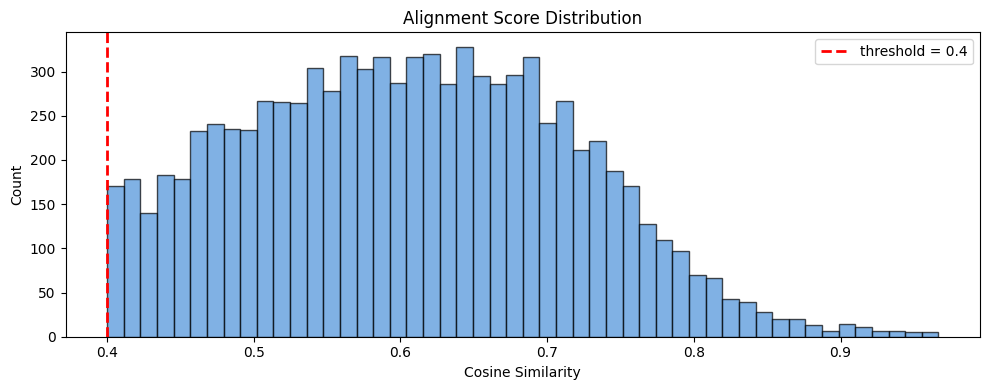

Total: 8833, mean=0.606, median=0.605

Surviving pairs at various thresholds:
  0.30:   8833  (100.0%)
  0.35:   8833  (100.0%)
  0.40:   8833  (100.0%)
  0.45:   8096  (91.7%)
  0.50:   7090  (80.3%)
  0.55:   5877  (66.5%)
  0.60:   4528  (51.3%)


In [28]:

import matplotlib.pyplot as plt

sfx = f"|{EXTRACTION_METHOD}|{SIM_THRESHOLD}"
scores = [a["score"] for k, d in alignment_cache.items()
          if k.endswith(sfx) for a in d["alignments"]]

if scores:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(scores, bins=50, edgecolor='black', alpha=0.7, color='#4a90d9')
    ax.axvline(SIM_THRESHOLD, color='red', ls='--', lw=2,
               label=f'threshold = {SIM_THRESHOLD}')
    ax.set_xlabel('Cosine Similarity'); ax.set_ylabel('Count')
    ax.set_title('Alignment Score Distribution'); ax.legend()
    plt.tight_layout(); plt.show()

    arr = np.array(scores)
    print(f"Total: {len(arr)}, mean={arr.mean():.3f}, median={np.median(arr):.3f}")
    print("\nSurviving pairs at various thresholds:")
    for t in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
        n = int(np.sum(arr >= t))
        print(f"  {t:.2f}:  {n:5d}  ({100*n/len(arr):.1f}%)")
else:
    print("No data - run 13e first.")


## 13g. Side-by-side display with alignment highlights

Hover over any underlined word to highlight its counterpart.
Darker blue = higher similarity score.

Set `DISPLAY_THRESHOLD` higher than `SIM_THRESHOLD` to filter the view
without re-running the model.

In [29]:

import html as html_lib

DISPLAY_THRESHOLD = SIM_THRESHOLD

def score_color(s):
    t = max(0.0, min(1.0, (s - 0.25) / 0.50))
    return f"rgb({int(74+(26-74)*t)},{int(144+(82-144)*t)},{int(217+(204-217)*t)})"

def render_aligned(ch, sec, g_text, e_text, data, thresh):
    als = [a for a in data.get("alignments", []) if a["score"] >= thresh]
    gt, et = data.get("grc_tokens", []), data.get("eng_tokens", [])
    if not als or not gt or not et:
        return (f'<td style="vertical-align:top">{html_lib.escape(g_text)}</td>'
                f'<td style="vertical-align:top">{html_lib.escape(e_text)}</td>')
    gm, em = {}, {}
    for idx, a in enumerate(als):
        pid = f"p{ch}_{sec}_{idx}"
        gm.setdefault(a["src_idx"], []).append((pid, a["score"]))
        em.setdefault(a["tgt_idx"], []).append((pid, a["score"]))
    def mk(toks, m):
        ps = []
        for i, tok in enumerate(toks):
            t = html_lib.escape(tok)
            if i in m:
                pids = " ".join(p for p, _ in m[i])
                best = max(s for _, s in m[i])
                c = score_color(best)
                ps.append(f'<span class="wa" data-p="{pids}" '
                          f'style="border-bottom:2px solid {c};cursor:pointer;padding:0 1px" '
                          f'title="sim={best:.3f}" '
                          f'onmouseenter="waOn(this)" onmouseleave="waOff(this)">{t}</span>')
            else:
                ps.append(t)
        return " ".join(ps)
    return (f'<td style="vertical-align:top">{mk(gt,gm)}</td>'
            f'<td style="vertical-align:top">{mk(et,em)}</td>')

JS = ('<style>.wa:hover,.wa.hl{background:#fff3cd!important;'
      'border-bottom-color:#e6a817!important}</style>'
      '<script>'
      'function waOn(el){el.getAttribute("data-p").split(" ").forEach(function(p){'
      'document.querySelectorAll("[data-p]").forEach(function(e){'
      'if(e.getAttribute("data-p").split(" ").indexOf(p)!==-1)e.classList.add("hl")})})}'
      'function waOff(el){el.getAttribute("data-p").split(" ").forEach(function(p){'
      'document.querySelectorAll("[data-p]").forEach(function(e){'
      'if(e.getAttribute("data-p").split(" ").indexOf(p)!==-1)e.classList.remove("hl")})})}'
      '</script>')

sfx = f"|{EXTRACTION_METHOD}|{SIM_THRESHOLD}"
parts = [JS]

for ch in sorted(grc_chs | eng_chs, key=section_sort_key):
    gd, ed = butcher.get(ch, {}), english.get(ch, {})
    secs = sorted(set(gd) | set(ed), key=section_sort_key)
    parts.append(
        f'<h3 style="margin-top:24px;border-bottom:2px solid #333;padding-bottom:4px">'
        f'Chapter {ch}</h3>'
        '<table border="1" cellpadding="8" style="border-collapse:collapse;width:100%;table-layout:fixed">'
        '<tr style="background:#f0f0f0"><th style="width:8%">\u00a7</th>'
        '<th style="width:46%">Greek (Butcher)</th>'
        '<th style="width:46%">English (Butcher)</th></tr>')
    for sec in secs:
        gt, et = gd.get(sec, ''), ed.get(sec, '')
        ck = f"{ch}.{sec}{sfx}"
        if gt and et and ck in alignment_cache:
            td = render_aligned(ch, sec, gt, et, alignment_cache[ck], DISPLAY_THRESHOLD)
        elif gt and not et:
            td = (f'<td style="vertical-align:top;background:#fff5f5">{html_lib.escape(gt)}</td>'
                  '<td style="vertical-align:top;background:#fff5f5;color:#aaa;font-style:italic">(no English)</td>')
        elif et and not gt:
            td = ('<td style="vertical-align:top;background:#f5fff5;color:#aaa;font-style:italic">(no Greek)</td>'
                  f'<td style="vertical-align:top;background:#f5fff5">{html_lib.escape(et)}</td>')
        else:
            td = (f'<td style="vertical-align:top">{html_lib.escape(gt)}</td>'
                  f'<td style="vertical-align:top">{html_lib.escape(et)}</td>')
        parts.append(f'<tr><td style="vertical-align:top;text-align:center;font-weight:bold">{sec}</td>{td}</tr>')
    parts.append('</table>')

display(HTML("\n".join(parts)))


## 13h. Alignment statistics and TSV export

In [30]:

sfx = f"|{EXTRACTION_METHOD}|{SIM_THRESHOLD}"
tot = sum(len(d["alignments"]) for k, d in alignment_cache.items() if k.endswith(sfx))
ns = sum(1 for k in alignment_cache if k.endswith(sfx))
shown = sum(1 for k, d in alignment_cache.items() if k.endswith(sfx)
            for a in d["alignments"] if a["score"] >= DISPLAY_THRESHOLD)

print(f"Method / threshold:  {EXTRACTION_METHOD} / {SIM_THRESHOLD}")
print(f"Display threshold:   {DISPLAY_THRESHOLD}")
print(f"Sections aligned:    {ns}")
print(f"Total pairs:         {tot}")
print(f"Pairs displayed:     {shown}")

tsv = "poetics_word_alignments.tsv"
with open(tsv, "w") as f:
    f.write("chapter\tsection\tgreek\tenglish\tsrc_idx\ttgt_idx\tscore\n")
    for key in sorted(alignment_cache):
        if not key.endswith(sfx): continue
        cs = key.split("|")[0]
        ch, sec = cs.split(".", 1)
        for a in alignment_cache[key]["alignments"]:
            f.write(f"{ch}\t{sec}\t{a['greek']}\t{a['english']}\t{a['src_idx']}\t{a['tgt_idx']}\t{a['score']}\n")
print(f"Exported to {tsv}")


Method / threshold:  itermax / 0.4
Display threshold:   0.4
Sections aligned:    380
Total pairs:         8833
Pairs displayed:     8833
Exported to poetics_word_alignments.tsv


## 14. Translation coverage statistics

In [31]:
total_grc = sum(len(ch) for ch in butcher.values())
total_eng = sum(len(ch) for ch in english.values())
aligned, only_grc, only_eng = 0, 0, 0

for ch in sorted(grc_chs | eng_chs, key=section_sort_key):
    g_secs = set(butcher.get(ch, {}).keys())
    e_secs = set(english.get(ch, {}).keys())
    aligned += len(g_secs & e_secs)
    only_grc += len(g_secs - e_secs)
    only_eng += len(e_secs - g_secs)

print('=' * 60)
print('PART B — GREEK ↔ ENGLISH SUMMARY')
print('=' * 60)
print(f'\n  Greek sections:     {total_grc}')
print(f'  English sections:   {total_eng}')
print(f'  Aligned pairs:      {aligned}')
print(f'  Only in Greek:      {only_grc}')
print(f'  Only in English:    {only_eng}')
if only_grc == 0 and only_eng == 0:
    print('\n✅ Perfect section alignment')
else:
    if only_grc > 0:
        print(f'\n⚠️  {only_grc} Greek sections have no English translation')
    if only_eng > 0:
        print(f'⚠️  {only_eng} English sections have no Greek counterpart')

PART B — GREEK ↔ ENGLISH SUMMARY

  Greek sections:     381
  English sections:   380
  Aligned pairs:      380
  Only in Greek:      1
  Only in English:    0

⚠️  1 Greek sections have no English translation
